# SOB4ES - Random Forest Multisalida

### CRISP-ML(Q) - Fase 3 y 4: Desarrollo y evaluación de los modelos

Este notebook implementa un **Random Forest con salida vectorial**: en lugar de entrenar un modelo independiente por cada variable objetivo, se entrena un único modelo que predice los 21 targets simultaneamente.

La clave de este enfoque es que cada nodo de cada árbol toma sus decisiones considerando todos los targets a la vez, lo que permite capturar correlaciones entre grupos biológicos. Por ejemplo, si la diversidad de lombrices y la de colémbolos tienden a co-variar, el modelo puede aprender esa relación.

**Datasets utilizados:**

- `train.csv` - Entrenamiento del modelo (70 % del total, estratificado por pais)
- `test.csv` - Busqueda de hiperparametros y validacion cruzada (15 %)
- `eval.csv` - Evaluacion final e imparcial del rendimiento (15 %)

**Estructura del notebook:**
1. **Configuración:** importaciones y parámetros globales.
2. **Carga de datos:** se cargan los tres splits pre-generados.
3. **Tuning:** búsqueda del valor óptimo de los hiperparámetros.
4. **Validación cruzada:** evaluación de robustez.
5. **Explicabilidad (SHAP):** análisis de importancia de variables.
6. **Producción:** entrenamiento final y exportación de modelos.
7. **Evaluación final:** rendimiento real sobre `eval.csv`.

## 1.- Configuración del entorno

En esta sección del notebook importaremos todas las librerías necesarias como también realizaremos las configuraciones iniciales.

In [1]:
import os
import time
import warnings
import joblib
import pandas as pd
import numpy as np
from pathlib import Path
import itertools

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

import shap

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, cross_validate, RepeatedKFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance

# Ignorar los warnings
warnings.filterwarnings('ignore')
os.environ["PYTHONWARNINGS"] = "ignore"

DATA_DIR   = 'input/'
MODELS_DIR = 'output/models/rf_multi/'
VAR_DIR = 'output/var'
Path(MODELS_DIR).mkdir(parents=True, exist_ok=True)
Path(VAR_DIR).mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

TARGETS = [
    # Shannon diversity index
    'nematode_shannon_z',
    'macro_shannon_z',
    'earthworm_shannon_z',
    'orib_shannon_z',
    'meso_shannon_z',
    'coll_shannon_z',
    'bac_shannon_z',
    'fun_shannon_z',
    'euk_shannon_z',
    'oomy_shannon_z',
    'cerc_shannon_z',
    # Richness
    'macro_order_richness_z',
    'earthworm_richness_z',
    'orib_species_richness_z',
    'meso_species_richness_z',
    'coll_species_richness_z',
    'bac_asv_richness_z',
    'fun_asv_richness_z',
    'euk_asv_richness_z',
    'oomy_asv_richness_z',
    'cerc_asv_richness_z'
]

FEATURES_AUTORIZADAS = [
    'total_plant_cover_z',
    'clay_content_z',
    'silt_content_z',
    'sand_content_z',
    'aggregate_stability_z',
    'bulk_density_z',
    'soil_moisture_z',
    'as_z',
    #'cu_z',
    'k_z',
    'mo_z',
    #'ni_z',
    'p_z',
    'pb_z',
    'zn_z',
    'soil_ph_z',
    'plot_total_organic_c_z',
    'plot_total_n_z',
    'gee_temp_media_C_z',
    'gee_humedad_rel_pct_z',
    'gee_ndvi_verano_z',
    'dem_elevacion_m_z',
    'dem_pendiente_deg_z',
    'dem_orientacion_deg_z',
    'eu_clay_content_z',
    'eu_sand_content_z',
    'eu_silt_content_z',
    'eu_water_holding_capacity_z',
    'eu_cn_ratio_z',
    'eu_p_z',
    'eu_ph_z',
    'eu_as_z',
    'eu_organic_carbon_octop_z',
    'eu_zn_z'
]


print('Librerias y variables cargadas correctamente...')


# Paleta de colores unificada
PALETTE = {
    'blue':         '#7FA6C9',
    'blue_light':   '#AAD0F1',
    'green':        '#7FC8A9',
    'green_light':  '#BEE6D3',
    'purple':       '#A98FC7',
    'purple_light': '#D6C7EA',
    'gray':         '#9B9B9B',
    'gray_dark':    '#5C5C5C',
}

# Secuencia ciclica para graficos con N series/categorias (N puede superar 6)
PALETTE_CYCLE = [PALETTE['blue'], PALETTE['green'], PALETTE['purple'],
                 PALETTE['blue_light'], PALETTE['green_light'], PALETTE['purple_light']]

def palette_cycle(n):
    """Devuelve una lista de n colores repitiendo PALETTE_CYCLE si hace falta."""
    return list(itertools.islice(itertools.cycle(PALETTE_CYCLE), n))

# Colormap secuencial (blanco -> azul -> morado) para heatmaps/matrices de confusion
PALETTE_CMAP = LinearSegmentedColormap.from_list(
    'sob4es_palette', ['#FFFFFF', PALETTE['purple_light'], PALETTE['purple']]
)


Librerias y variables cargadas correctamente...


In [2]:
# Ajuste automatico de n_jobs segun los nucleos disponibles
# Evita saturar la maquina (todos los procesos a la vez con n_jobs=-1)

def get_n_jobs(fraccion=0.75, reserva=1):
    """Calcula un n_jobs seguro dejando al menos `reserva` nucleos libres
    para que el sistema no se vuelva inutilizable durante la ejecucion."""
    n_cpu = os.cpu_count() or 1
    n_usar = max(1, min(int(n_cpu * fraccion), n_cpu - reserva))
    return n_usar

N_JOBS = get_n_jobs()
print(f'Nucleos disponibles: {os.cpu_count()} | n_jobs asignado: {N_JOBS}')

Nucleos disponibles: 20 | n_jobs asignado: 15


## 2.- Carga de datos

Se cargan los tres datasets pre-generados a partir de la división 70/15/15 estratificada por país.

| Archivo     | Uso                                      | Filas aprox. |
| ----------- | ---------------------------------------- | ------------ |
| `train.csv` | Ajuste del modelo                        | 299          |
| `test.csv`  | Tuning de hiperparametros / Val. cruzada | 64           |
| `eval.csv`  | Evaluacion final imparcial               | 65           |

El dataset `eval.csv` no se utiliza hasta la sección 7 para garantizar una estimación imparcial del rendimiento.

In [3]:
def cargar_csv(ruta, nombre):
    if not os.path.exists(ruta):
        raise FileNotFoundError(f'No se encontro: {ruta}')
    try:
        df = pd.read_csv(ruta, sep=',')
        if len(df.columns) < 5:
            df = pd.read_csv(ruta, sep=';')
    except Exception:
        df = pd.read_csv(ruta, sep=';')
    print(f'  {nombre}: {df.shape[0]} filas x {df.shape[1]} columnas')
    return df
print("Cargando datasets...")
df_train = cargar_csv(os.path.join(DATA_DIR, 'train.csv'), 'train.csv')
df_test  = cargar_csv(os.path.join(DATA_DIR, 'test.csv'),  'test.csv')
df_eval  = cargar_csv(os.path.join(DATA_DIR, 'eval.csv'),  'eval.csv')

X_train = df_train[FEATURES_AUTORIZADAS]
y_train = df_train[TARGETS]

X_test  = df_test[FEATURES_AUTORIZADAS]
y_test  = df_test[TARGETS]

X_eval  = df_eval[FEATURES_AUTORIZADAS]   # no se usa hasta la seccion 7
y_eval  = df_eval[TARGETS]               # no se usa hasta la seccion 7

print(f"\nDatasets cargados.")
print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}  |  X_eval: {X_eval.shape}")
print(f"y_train: {y_train.shape}  |  y_test: {y_test.shape}  |  y_eval: {y_eval.shape}")

Cargando datasets...
  train.csv: 299 filas x 71 columnas
  test.csv: 64 filas x 71 columnas
  eval.csv: 65 filas x 71 columnas

Datasets cargados.
X_train: (299, 32)  |  X_test: (64, 32)  |  X_eval: (65, 32)
y_train: (299, 21)  |  y_test: (64, 21)  |  y_eval: (65, 21)


## 3.- Búsqueda de hiperparámetros (Tuning)

La búsqueda de hiperparámetros es idéntica a la del Random Forest individual. 

El modelo acepta `y` como matriz 2D de forma transparente, por lo que el espacio de búsqueda no cambia.

La búsqueda se realiza sobre `X_train` y `y_train` (todos los targets a la vez).

Iniciando busqueda de hiperparametros...
Este proceso puede tardar bastante...



[ 1/21] | [nematode_shannon_z       ] R2: 0.2158  |  tiempo: 0.2 min


[ 2/21] | [macro_shannon_z          ] R2: 0.2497  |  tiempo: 0.1 min


[ 3/21] | [earthworm_shannon_z      ] R2: 0.4369  |  tiempo: 0.1 min


[ 4/21] | [orib_shannon_z           ] R2: 0.1046  |  tiempo: 0.1 min


...

[17/21] | [bac_asv_richness_z       ] R2: 0.1057  |  tiempo: 0.1 min


[18/21] | [fun_asv_richness_z       ] R2: -0.0241  |  tiempo: 0.1 min


[19/21] | [euk_asv_richness_z       ] R2: 0.2150  |  tiempo: 0.1 min


[20/21] | [oomy_asv_richness_z      ] R2: 0.2354  |  tiempo: 0.1 min


[21/21] | [cerc_asv_richness_z      ] R2: 0.1966  |  tiempo: 0.1 min

Calculando consenso de hiperparametros (ponderado por R2 de los 21 targets)...
  Peso earthworm_richness_z          : 0.136
  Peso earthworm_shannon_z           : 0.119
  Peso macro_shannon_z               : 0.068
  Peso macro_order_richness_z        : 0.066
  Peso oomy_asv_richness_z           : 0.064
  ...

Hiperparametros consenso finales:
  n_estimators: 269
  max_depth: 7
  min_samples_split: 15
  min_samples_leaf: 4
  max_features: log2
  ccp_alpha: 0.0002879078231482851
  bootstrap: True
  max_samples: 0.6839645830362007
  max_leaf_nodes: None
  random_state: 42
  n_jobs: 15


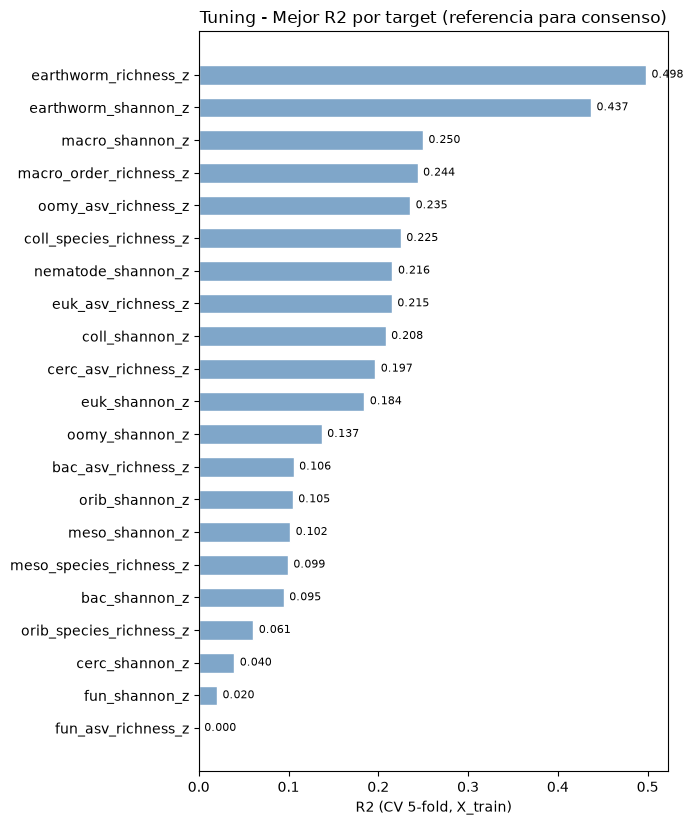

In [4]:
print('Iniciando busqueda de hiperparametros...')
print('Este proceso puede tardar bastante...\n')

param_grid = {
	'n_estimators':      [150, 250, 350],
	'max_depth':         [3, 5, 7, 10],
	'min_samples_split': [10, 20, 30, 50],
	'min_samples_leaf':  [4, 8, 12, 16],
	'max_features':      ['sqrt', 'log2', 0.2, 0.3, 0.4],
	'criterion':         ['squared_error', 'friedman_mse'],
	'ccp_alpha':         [0.0, 0.001, 0.01, 0.05],
	'bootstrap':         [True],
	'max_samples':       [0.5, 0.7, 0.8],
	'random_state':      [RANDOM_STATE],
}
resultados_tuning = {}

for idx, nombre_target in enumerate(TARGETS, 1):
    buscador = RandomizedSearchCV(
        estimator=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=N_JOBS),
        param_distributions=param_grid,
        n_iter=150,
        scoring='r2', 
        cv=5,
        verbose=0, 
        random_state=RANDOM_STATE, 
        n_jobs= N_JOBS
    )
    start = time.time()
    buscador.fit(X_train, y_train[nombre_target].values)
    elapsed = (time.time() - start) / 60

    resultados_tuning[nombre_target] = {
        'params': buscador.best_params_,
        'r2':     buscador.best_score_,
    }
    print(f'[{idx:2d}/{len(TARGETS)}] | [{nombre_target:<25}] R2: {buscador.best_score_:.4f}  |  tiempo: {elapsed:.1f} min')

# Consenso de hiperparametros ponderado por R2 (ahora sobre los 21 targets)
r2_por_target = {t: max(resultados_tuning[t]['r2'], 0.0) for t in TARGETS}
suma_r2 = sum(r2_por_target.values())
if suma_r2 <= 0:
    pesos = {t: 1 / len(TARGETS) for t in TARGETS}
else:
    pesos = {t: v / suma_r2 for t, v in r2_por_target.items()}

print('\nCalculando consenso de hiperparametros (ponderado por R2 de los 21 targets)...')
for t in sorted(pesos, key=pesos.get, reverse=True)[:5]:
    print(f'  Peso {t:30}: {pesos[t]:.3f}')
print('  ...')

def consenso_int(key, default=0):
    return int(round(sum(pesos[t] * resultados_tuning[t]['params'].get(key, default) for t in TARGETS)))

def consenso_float(key, default=0.0):
    return sum(pesos[t] * resultados_tuning[t]['params'].get(key, default) for t in TARGETS)

def consenso_cat(key):
    mejor_target = max(pesos, key=pesos.get)
    return resultados_tuning[mejor_target]['params'][key]

def consenso_none_or_int(key):
    items = {t: resultados_tuning[t]['params'].get(key) for t in TARGETS}
    items = {t: v for t, v in items.items() if v is not None}
    if not items:
        return None
    suma_sub = sum(pesos[t] for t in items)
    sub_pesos = {t: (pesos[t] / suma_sub if suma_sub > 0 else 1 / len(items)) for t in items}
    return int(round(sum(sub_pesos[t] * items[t] for t in items)))

def consenso_none_or_float(key):
    items = {t: resultados_tuning[t]['params'].get(key) for t in TARGETS}
    items = {t: v for t, v in items.items() if v is not None}
    if not items:
        return None
    suma_sub = sum(pesos[t] for t in items)
    sub_pesos = {t: (pesos[t] / suma_sub if suma_sub > 0 else 1 / len(items)) for t in items}
    return sum(sub_pesos[t] * items[t] for t in items)

RF_MULTI_PARAMS = {
    'n_estimators':             consenso_int('n_estimators'),
    'max_depth':                consenso_none_or_int('max_depth'),
    'min_samples_split':        consenso_int('min_samples_split'),
    'min_samples_leaf':         consenso_int('min_samples_leaf'),
    'max_features':             consenso_cat('max_features'),
    'ccp_alpha':                consenso_float('ccp_alpha'),
    'bootstrap':                consenso_cat('bootstrap'),
    'max_samples':              consenso_none_or_float('max_samples'),
    'max_leaf_nodes':           consenso_none_or_int('max_leaf_nodes'),
    'random_state':             RANDOM_STATE,
    'n_jobs':                   N_JOBS,
}

print('\nHiperparametros consenso finales:')
for k, v in RF_MULTI_PARAMS.items():
    print(f'  {k}: {v}')

# Grafico: R2 de tuning por target (ordenado)
_orden = sorted(r2_por_target, key=r2_por_target.get)
fig, ax = plt.subplots(figsize=(7, 0.35 * len(_orden) + 1))
_bars = ax.barh([t for t in _orden], [r2_por_target[t] for t in _orden], color=PALETTE['blue'], edgecolor='white', height=0.6)
ax.bar_label(_bars, fmt='{:.3f}', padding=4, fontsize=8)
ax.set_xlabel('R2 (CV 5-fold, X_train)')
ax.set_title('Tuning - Mejor R2 por target (referencia para consenso)', fontsize=12)
ax.axvline(0, color=PALETTE['gray'], linewidth=0.8)
plt.tight_layout()
plt.show()

## 4.- Validación cruzada

Se evalua la robustez del modelo con **validación cruzada repetida** (5 pliegues x 3 repeticiones). 

Al ser multisalida, el R2 que reporta sklearn es el promedio sobre todos los targets. 

Se muestra tambien el R2 individual por target para identificar cuales aprende mejor el modelo.

In [5]:
print('Validacion cruzada repetida sobre X_train (todos los targets)...\n')

modelo_cv   = RandomForestRegressor(**RF_MULTI_PARAMS)
cv_splitter = RepeatedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)

resultados = cross_validate(
    estimator=modelo_cv,
    X=X_train,
    y=y_train,
    cv=cv_splitter,
    return_train_score=True,
    n_jobs=N_JOBS
)

r2_train = np.mean(resultados['train_score'])
r2_cv    = np.mean(resultados['test_score'])
r2_std   = np.std(resultados['test_score'])

print(f'  Train R2 (promedio targets): {r2_train:.4f}')
print(f'  Val   R2 (promedio targets): {r2_cv:.4f} +/- {r2_std:.4f}')

# R2 individual por target (entrenando sobre todo X_train)
modelo_cv.fit(X_train, y_train)
y_pred_train = modelo_cv.predict(X_train)
print('\n  R2 por target (train):')
for i, t in enumerate(TARGETS):
    r2 = r2_score(y_train.iloc[:, i], y_pred_train[:, i])
    print(f'    {t:30} {r2:.4f}')

diferencia = r2_train - r2_cv
estado = 'Aviso: Posible sobreajuste' if diferencia > 0.15 else 'OK'
    
print("Resultados globales (promedio targets):")
print(f"{"R2 global":<25} | {r2_train:<10.3f} | {r2_cv:<10.3f} | {diferencia:<10.3f} | {estado}")

Validacion cruzada repetida sobre X_train (todos los targets)...



  Train R2 (promedio targets): 0.3121
  Val   R2 (promedio targets): 0.1445 +/- 0.0173

  R2 por target (train):
    nematode_shannon_z             0.3789
    macro_shannon_z                0.3840
    earthworm_shannon_z            0.5399
    orib_shannon_z                 0.2934
    meso_shannon_z                 0.2710
    coll_shannon_z                 0.4104
    bac_shannon_z                  0.2411
    fun_shannon_z                  0.1876
    euk_shannon_z                  0.3034
    oomy_shannon_z                 0.2838
    cerc_shannon_z                 0.1804
    macro_order_richness_z         0.3694
    earthworm_richness_z           0.5817
    orib_species_richness_z        0.3187
    meso_species_richness_z        0.2567
    coll_species_richness_z        0.4230
    bac_asv_richness_z             0.2339
    fun_asv_richness_z             0.1200


    euk_asv_richness_z             0.3442
    oomy_asv_richness_z            0.3202
    cerc_asv_richness_z            0.3433
Resultados globales (promedio targets):
R2 global                 | 0.312      | 0.145      | 0.168      | Aviso: Posible sobreajuste


## 5.- Importancia de variables

Se calcula la importancia de variables mediante permutación sobre `X_train`. 

Al ser multisalida, la importancia refleja el impacto de cada variable sobre el conjunto de todos los targets simultaneamente.

También se calcula las variables SHAPley para una mejor interpretabilidad del modelo en conjunto.

Top 10 variables por importancia global (todos los targets):
soil_ph_z                0.0432
gee_temp_media_C_z       0.0374
eu_as_z                  0.0331
eu_p_z                   0.0260
gee_humedad_rel_pct_z    0.0228
eu_ph_z                  0.0220
p_z                      0.0197
eu_cn_ratio_z            0.0184
eu_clay_content_z        0.0171
sand_content_z           0.0170


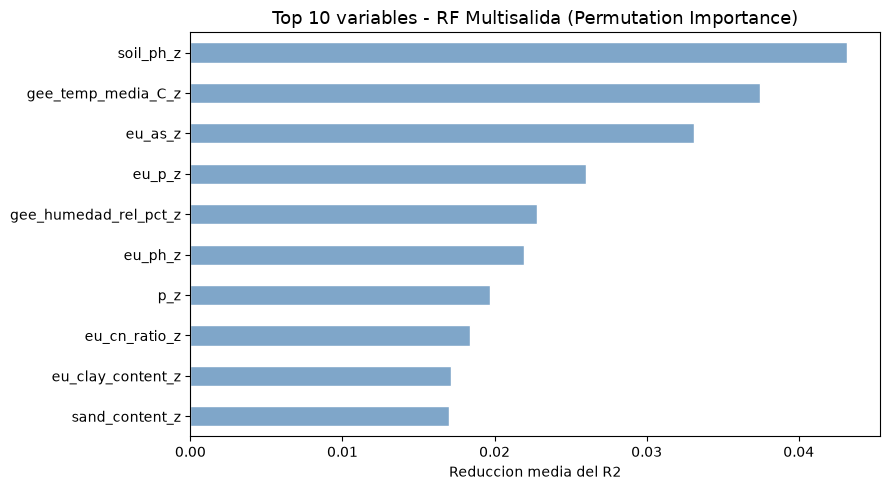


Datos exportados correctamente para revisión en: 'output/var/variables_mas_relevantes_rf_multisalida.csv'

Top 10 variables menos relevantes (todos los targets):
dem_orientacion_deg_z          0.0017
mo_z                           0.0024
aggregate_stability_z          0.0025
total_plant_cover_z            0.0027
dem_pendiente_deg_z            0.0037
bulk_density_z                 0.0047
as_z                           0.0057
plot_total_organic_c_z         0.0059
eu_water_holding_capacity_z    0.0062
k_z                            0.0066


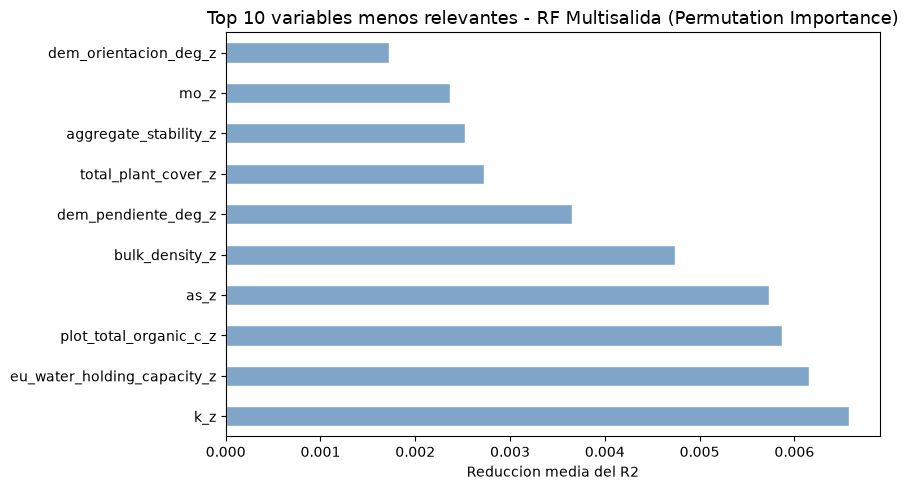


Datos exportados correctamente para revisión en: 'output/var/variables_menos_relevantes_rf_multisalida.csv'
Calculando valores SHAP (RF Multisalida)...


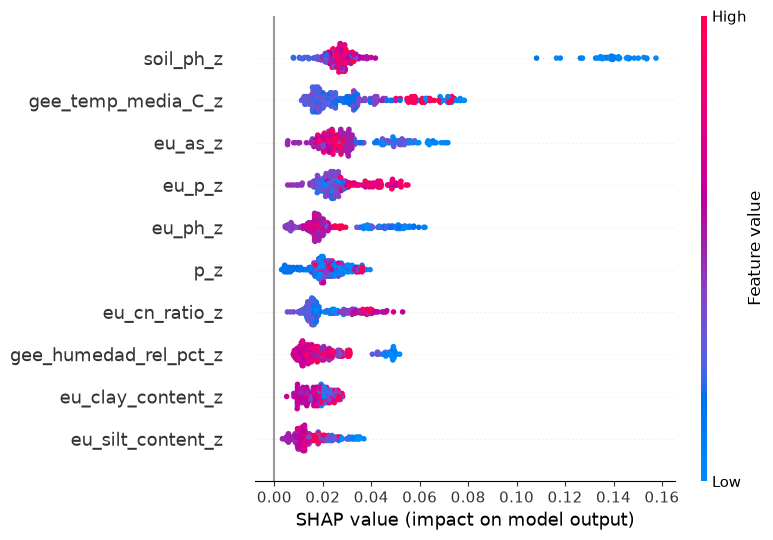

In [6]:
# El modelo ya esta ajustado sobre y_train completo desde la celda anterior
perm = permutation_importance(
    modelo_cv, X_train, y_train,
    n_repeats=10, random_state=42, n_jobs=-1
)

importancias = pd.Series(perm.importances_mean, index=FEATURES_AUTORIZADAS)
top10 = importancias.nlargest(10)

print('Top 10 variables por importancia global (todos los targets):')
print(top10.round(4).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
importancias.nlargest(10).sort_values().plot(kind='barh', ax=ax, color=PALETTE['blue'], edgecolor='white')
ax.set_title('Top 10 variables - RF Multisalida (Permutation Importance)', fontsize=13)
ax.set_xlabel('Reduccion media del R2')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

# Exportación
csv_path = 'output/var/variables_mas_relevantes_rf_multisalida.csv'
top10.rename_axis('variable').reset_index(name='importancia').to_csv(csv_path, index=False)
print(f"\nDatos exportados correctamente para revisión en: '{csv_path}'")

bottom10 = importancias.nsmallest(10)

print('\nTop 10 variables menos relevantes (todos los targets):')
print(bottom10.round(4).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
importancias.nsmallest(10).sort_values(ascending=False).plot(kind='barh', ax=ax, color=PALETTE['blue'], edgecolor='white')
ax.set_title('Top 10 variables menos relevantes - RF Multisalida (Permutation Importance)', fontsize=13)
ax.set_xlabel('Reduccion media del R2')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

csv_path = 'output/var/variables_menos_relevantes_rf_multisalida.csv'
bottom10.rename_axis('variable').reset_index(name='importancia').to_csv(csv_path, index=False)
print(f"\nDatos exportados correctamente para revisión en: '{csv_path}'")

import shap

print('Calculando valores SHAP (RF Multisalida)...')
explainer   = shap.TreeExplainer(modelo_cv)
shap_values = explainer.shap_values(X_train)

# Si shap_values es 3D (multisalida), promediamos el valor absoluto sobre todos los targets
if isinstance(shap_values, list):
    shap_mean = np.mean([np.abs(sv) for sv in shap_values], axis=0)
elif shap_values.ndim == 3:
    shap_mean = np.abs(shap_values).mean(axis=2)
else:
    shap_mean = shap_values

shap.summary_plot(shap_mean, X_train, plot_type='dot', max_display=10, show=True)

## 6.- Entrenamiento de producción

Se entrena un ensamble de 5 modelos multisalida, variando la semilla aleatoria (semilla + n_modelo).

Cada modelo predice los 21 targets a la vez. Promediar el ensamble reduce la varianza de las predicciones finales.

In [7]:
print('Entrenamiento de produccion (ensamble de 5 modelos multisalida)...')
print('-' * 70)

global_start = time.time()
NUM_MODELOS  = 5

for seed_id in range(NUM_MODELOS):
    t0     = time.time()
    params = RF_MULTI_PARAMS.copy()
    params['random_state'] = RANDOM_STATE + seed_id

    # Entrenamos sobre y_train completo (matriz 11 targets)
    model  = RandomForestRegressor(**params)
    model.fit(X_train, y_train)

    joblib.dump(model, os.path.join(MODELS_DIR, f'rf_multi_m{seed_id}.pkl'))
    print(f'  Modelo {seed_id+1}/5 completado ({time.time()-t0:.1f}s)')

print('-' * 70)
print(f'Produccion completada en {(time.time()-global_start)/60:.1f} minutos.')

Entrenamiento de produccion (ensamble de 5 modelos multisalida)...
----------------------------------------------------------------------


  Modelo 1/5 completado (0.2s)
  Modelo 2/5 completado (0.2s)


  Modelo 3/5 completado (0.2s)
  Modelo 4/5 completado (0.2s)


  Modelo 5/5 completado (0.2s)
----------------------------------------------------------------------
Produccion completada en 0.0 minutos.


## 7.- Evaluación final sobre eval.csv

Se usa `eval.csv` por primera vez para obtener una estimación real del rendimiento en producción. 
A continuación se ejecuta un smoke test para verificar que el pipeline de carga e inferencia funciona correctamente.

**Nota: Interpretacion del indice Shannon H':**

El modelo predice el índice de diversidad de Shannon, que va aproximadamente de `0.0` (sin diversidad) a `4.0-5.0` (alta diversidad biologica).

Evaluacion final sobre eval.csv
------------------------------------------------------------


  R2   global: 0.0968
  RMSE global: 0.9193 (Z-score)
  MAE  global: 0.7020 (Z-score)

  R2 por target:
    nematode_shannon_z             0.1514
    macro_shannon_z                0.1966
    earthworm_shannon_z            0.4249
    orib_shannon_z                 0.1682
    meso_shannon_z                 -0.1272
    coll_shannon_z                 -0.1996
    bac_shannon_z                  0.0476
    fun_shannon_z                  -0.0187
    euk_shannon_z                  0.1371
    oomy_shannon_z                 0.1222
    cerc_shannon_z                 -0.0037
    macro_order_richness_z         0.2520
    earthworm_richness_z           0.4703
    orib_species_richness_z        0.2335
    meso_species_richness_z        -0.0293
    coll_species_richness_z        -0.3157
    bac_asv_richness_z             0.0136
    fun_asv_richness_z             -0.0058
    euk_asv_richness_z             0.1937
    oomy_asv_richness_z            0.1992
    cerc_asv_richness_z            0.1217

Smoke 


  Target: earthworm_shannon_z
  ----------------------------------------------------------
    Fila 53   | Prediccion:  0.3956 | Valor Real:  1.1347 | Error: 0.7391
    Fila 60   | Prediccion:  0.5548 | Valor Real:  1.1388 | Error: 0.5839
    Fila 0    | Prediccion: -0.3652 | Valor Real: -0.7453 | Error: 0.3801

  Target: earthworm_richness_z
  ----------------------------------------------------------
    Fila 53   | Prediccion:  0.5034 | Valor Real:  1.4889 | Error: 0.9855
    Fila 60   | Prediccion:  0.7046 | Valor Real:  1.1147 | Error: 0.4101
    Fila 0    | Prediccion: -0.3881 | Valor Real: -0.7562 | Error: 0.3682

------------------------------------------------------------
Smoke test superado. El pipeline multisalida funciona correctamente.


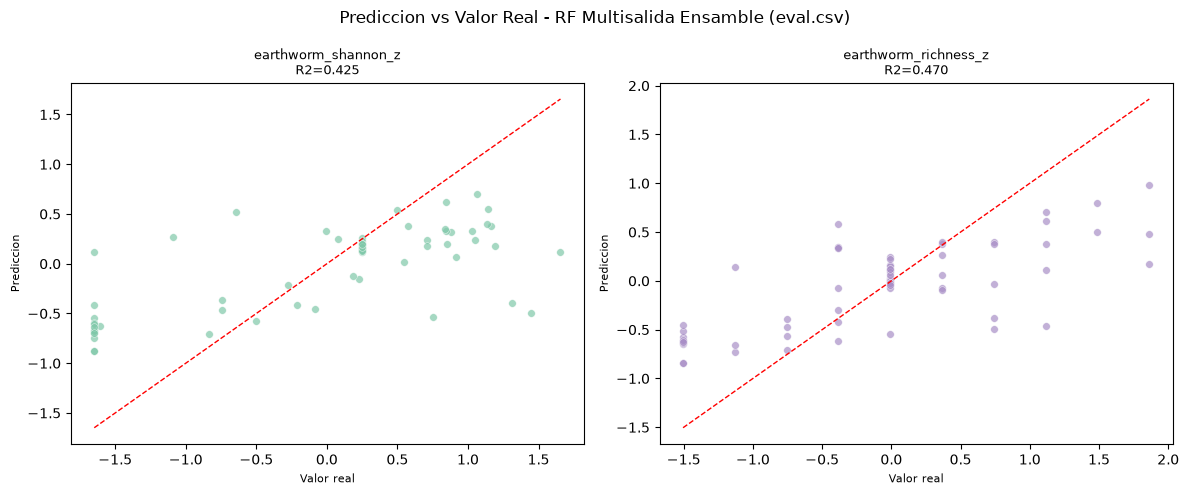

In [8]:
NUM_MODELOS = 5

# Evaluacion final
# Cargamos los 5 modelos y promediamos sus predicciones sobre eval.csv.

print('Evaluacion final sobre eval.csv')
print('-' * 60)

preds_eval = []
for seed_id in range(NUM_MODELOS):
    ruta  = os.path.join(MODELS_DIR, f'rf_multi_m{seed_id}.pkl')
    model = joblib.load(ruta)
    preds_eval.append(model.predict(X_eval))

# y_pred_eval es una matriz (n_muestras x len(TARGETS) targets)
y_pred_eval = np.mean(preds_eval, axis=0)
y_true_eval = y_eval.values

# Metricas globales (promedio sobre todos los targets)
r2_global   = r2_score(y_true_eval, y_pred_eval, multioutput='uniform_average')
rmse_global = np.sqrt(mean_squared_error(y_true_eval, y_pred_eval, multioutput='uniform_average'))
mae_global  = mean_absolute_error(y_true_eval, y_pred_eval, multioutput='uniform_average')


print(f'  R2   global: {r2_global:.4f}')
print(f'  RMSE global: {rmse_global:.4f} (Z-score)')
print(f'  MAE  global: {mae_global:.4f} (Z-score)')

# R2 individual por target
print('\n  R2 por target:')
r2_por_target = r2_score(y_true_eval, y_pred_eval, multioutput='raw_values')
for t, r2 in zip(TARGETS, r2_por_target):
    print(f'    {t:30} {r2:.4f}')

# Smoke test con datos reales
print('\nSmoke test - Inferencia con datos reales')
print('-' * 60)

try:
    df_new_data      = X_eval.sample(n=3, random_state=RANDOM_STATE)
    indices_elegidos = df_new_data.index

    # Generamos las predicciones de todos los modelos del ensamble
    votos = []
    for seed_id in range(NUM_MODELOS):
        ruta  = os.path.join(MODELS_DIR, f'rf_multi_m{seed_id}.pkl')
        m     = joblib.load(ruta)
        pred  = m.predict(df_new_data)
        votos.append(pred)

    # Promediamos para obtener el consenso final del ensamble
    consenso = np.mean(votos, axis=0)
    
    # Lista de targets a inspeccionar en el smoke test
    targets_smoke = ['earthworm_shannon_z', 'earthworm_richness_z']
    
    for tgt in targets_smoke:
        tgt_idx = TARGETS.index(tgt)
        print(f'\n  Target: {tgt}')
        print('  ' + '-' * 58)
        
        for i, idx in enumerate(indices_elegidos):
            pred_val = consenso[i, tgt_idx]
            real_val = y_eval.loc[idx, tgt]
            error    = abs(pred_val - real_val)
            print(f'    Fila {idx:<4} | Prediccion: {pred_val:>7.4f} | '
                  f'Valor Real: {real_val:>7.4f} | Error: {error:>6.4f}')

    print('\n' + '-' * 60)
    print('Smoke test superado. El pipeline multisalida funciona correctamente.')

except Exception as e:
    print(f'Error en el smoke test: {str(e)}')

# Grafico: scatter prediccion vs valor real (earthworm_shannon_z y earthworm_richness_z)
_targets_plot = ['earthworm_shannon_z', 'earthworm_richness_z']
_colors_plot  = [PALETTE['green'], PALETTE['purple']]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, tgt, col in zip(axes, _targets_plot, _colors_plot):
    preds = [joblib.load(os.path.join(MODELS_DIR, f'rf_multi_m{i}.pkl')).predict(X_eval)
             for i in range(NUM_MODELOS)]
    yp = np.mean(preds, axis=0)[:, TARGETS.index(tgt)]
    yt = y_eval[tgt].values
    
    ax.scatter(yt, yp, alpha=0.7, s=30, color=col, edgecolors='white', linewidths=0.4)
    lim = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lim, lim, 'r--', linewidth=1)
    
    ax.set_title(f'{tgt}\nR2={r2_score(yt, yp):.3f}', fontsize=9)
    ax.set_xlabel('Valor real', fontsize=8)
    ax.set_ylabel('Prediccion', fontsize=8)
    
plt.suptitle('Prediccion vs Valor Real - RF Multisalida Ensamble (eval.csv)', fontsize=12)
plt.tight_layout()
plt.show()